In [1]:
import numpy as np
import pandas as pd
import random
import geopandas as gpd
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *
from preprocessing_utils import process_greek

enc = 'utf-8'
shapefiles_folder = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [4]:
MONTH = 'June'
PERIOD = '1st'

In [5]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

months: 6, 7, 8, 9, 10, 
years: 2010, 2011, 2012, 2013, 2018, 2019, 2020, 2021, 


In [6]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2022_Cases_Dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 11, 
years: 2022, 


In [7]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'
path2 = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2022.csv'

In [8]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.390000,11.935000,6.845,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,0.015560,0.015560,0.015560,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,5,0,0
1,21.94079,40.97703,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.48134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.657273,11.324545,5.990,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,0.248551,0.248551,0.248551,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,0,0
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,7,0,0
3,23.98253,40.91510,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.42581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.742500,13.120000,8.365,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,0.055994,0.055994,0.055994,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,20,0,0
4,23.69108,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,747.0,16994.0,24.5,46.91682,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.0,0.0,0.0,0.0,11.447500,15.240000,7.655,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,1.750566,1.750566,1.750566,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,4,0,0


In [9]:
#Check months

dataset = dataset.query('month >= 5 & month <= 11')
dataset.reset_index(inplace=True, drop=True)

In [10]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-05-01,κεντρικης μακεδονιας,αλεξανδρειας,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.940000,37.000000,12.880000,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,0.809564,44.020006,510.573984,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,5,10,0
1,21.94079,40.97703,2010-05-01,κεντρικης μακεδονιας,αλμωπιας,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,985.8,24924.0,28.0,46.48134,0.464576,0.117994,-0.304247,-0.117994,0.465011,0.112118,-0.316092,-0.112118,0.042922,0.045635,0.040306,0.045635,15.800909,21.191818,10.410000,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,15.638457,72.293222,585.783832,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,2,0
2,22.89198,40.65603,2010-05-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,9.8,49674.0,5319.1,46.65786,0.170802,0.062868,-0.101038,-0.062868,0.166419,0.052195,-0.123815,-0.052195,0.085079,0.060522,0.023502,0.060522,22.320000,30.450000,14.190000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,3.478170,46.557858,498.499728,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,7,14,0
3,23.98253,40.91510,2010-05-01,κεντρικης μακεδονιας,αμφιπολης,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,411.8,7169.0,22.3,47.42581,0.547689,0.283147,-0.236768,-0.283147,0.529543,0.260121,-0.241848,-0.260121,0.045883,0.056681,0.032820,0.056681,18.150000,25.555000,10.745000,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,5.320219,20.416900,562.487645,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,20,40,0
4,23.69108,40.49593,2010-05-01,κεντρικης μακεδονιας,αριστοτελη,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,747.0,16994.0,24.5,46.91682,0.627781,0.340199,-0.222800,-0.340199,0.615380,0.333255,-0.223689,-0.333255,0.038539,0.035731,0.051137,0.035731,15.963750,21.550000,10.377500,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,7.791984,33.142172,508.453069,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,4,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6675,22.14670,40.82294,2021-08-16,κεντρικης μακεδονιας,σκυδρας,16,8,33,2021,-0.101168,-0.994869,-0.866025,-0.500000,-0.696551,-0.717507,239.5,18080.0,84.3,46.44339,0.445122,0.014416,-0.427180,-0.014416,0.443690,0.017735,-0.421358,-0.017735,0.118285,0.115395,0.067481,0.115395,30.280000,37.640000,22.920000,8.027348,-1.694000,16.188258,3.720184,18.653647,3.363529,23.454958,6.352353,4.010308,12.030641,692.442186

In [11]:
dataset2 = read_data(path2, exclude_years = years_to_remove)
dataset2.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2022-01-01,κεντρικης μακεδονιας,αλεξανδρειας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.450000,8.126419,-1.340303,16.216012,1.011667,18.020179,1.565813,32.641755,8.896456,0.113685,0.113685,0.113685,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,26,0,0
1,21.94079,40.97703,2022-01-01,κεντρικης μακεδονιας,αλμωπιας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,985.8,24924.0,28.0,46.48134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.810778,12.236000,7.385556,5.156188,-0.429920,9.002046,1.203846,8.268402,0.655058,20.890796,6.749332,2.557299,2.557299,2.557299,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,0,0
2,22.89198,40.65603,2022-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.770000,8.206667,1.223333,14.106000,3.702000,17.271538,2.883846,26.801250,9.896667,0.000000,0.000000,0.000000,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,26,0,0
3,23.98253,40.91510,2022-01-01,κεντρικης μακεδονιας,αμφιπολης,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,411.8,7169.0,22.3,47.42581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.935000,5.506350,-0.849211,10.168715,1.184231,13.528745,0.333718,22.552471,8.162000,0.417504,0.417504,0.417504,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,79,20,79.0,20,79,9,9,4,1,1,2,0,26,0,0
4,23.69108,40.49593,2022-01-01,κεντρικης μακεδονιας,αριστοτελη,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,747.0,16994.0,24.5,46.91682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.014583,9.186667,6.842500,5.626176,0.027273,8.827055,1.857362,12.089767,0.979534,20.756913,8.392523,0.000000,0.000000,0.000000,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,0,0


In [12]:
#Check months

dataset2 = dataset2.query('month >= 5 & month <= 11')
dataset2.reset_index(inplace=True, drop=True)

In [13]:
dataset2

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2022-05-01,κεντρικης μακεδονιας,αλεξανδρειας,1,5,17,2022,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,478.8,38293.0,86.8,46.44911,0.150148,-0.115028,-0.195258,0.115028,0.163415,-0.098778,-0.204886,0.098778,0.050573,0.036025,0.041401,0.036025,24.360000,34.675000,14.045000,8.126419,-1.340303,16.216012,1.011667,18.020179,1.565813,32.641755,8.896456,1.730230,12.411778,277.007093,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.000000,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,26,52,0
1,21.94079,40.97703,2022-05-01,κεντρικης μακεδονιας,αλμωπιας,1,5,17,2022,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,985.8,24924.0,28.0,46.48134,0.427224,0.115145,-0.363691,-0.115145,0.470158,0.144329,-0.390226,-0.144329,0.052825,0.053414,0.038587,0.053414,16.414545,21.631818,11.197273,5.156188,-0.429920,9.002046,1.203846,8.268402,0.655058,20.890796,6.749332,23.695157,41.199878,401.502300,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.000000,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,2,0
2,22.89198,40.65603,2022-05-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,5,17,2022,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,9.8,49674.0,5319.1,46.65786,0.155577,0.027760,-0.176065,-0.027760,0.186622,0.026571,-0.205055,-0.026571,0.085134,0.054018,0.065859,0.054018,21.370000,30.250000,12.490000,8.206667,1.223333,14.106000,3.702000,17.271538,2.883846,26.801250,9.896667,4.788772,33.317951,398.092486,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.000000,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,26,52,0
3,23.98253,40.91510,2022-05-01,κεντρικης μακεδονιας,αμφιπολης,1,5,17,2022,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,411.8,7169.0,22.3,47.42581,0.527262,0.199339,-0.449079,-0.199339,0.497027,0.184929,-0.424671,-0.184929,0.063080,0.071608,0.052506,0.071608,17.805000,23.055000,12.555000,5.506350,-0.849211,10.168715,1.184231,13.528745,0.333718,22.552471,8.162000,3.488782,5.303732,345.048255,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.000000,116.778232,22,79,20,79.0,20,79,9,9,4,1,1,2,0,26,52,0
4,23.69108,40.49593,2022-05-01,κεντρικης μακεδονιας,αριστοτελη,1,5,17,2022,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,747.0,16994.0,24.5,46.91682,0.587577,0.231328,-0.483484,-0.231328,0.618911,0.241858,-0.504882,-0.241858,0.043972,0.048349,0.028581,0.048349,16.272500,19.600000,12.945000,5.626176,0.027273,8.827055,1.857362,12.089767,0.979534,20.756913,8.392523,8.795817,16.715962,569.260289,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.000000,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,22.48398,40.64468,2022-08-16,κεντρικης μακεδονιας,αλεξανδρειας,16,8,33,2022,-0.101168,-0.994869,-0.866025,-0.500000,-0.696551,-0.717507,478.8,38293.0,86.8,46.44911,0.694571,0.353325,-0.589602,-0.353325,0.685882,0.343081,-0.584848,-0.343081,0.043877,0.051278,0.035686,0.051278,25.332500,31.340000,19.325000,8.126419

In [14]:
dataset['lau1'].unique().shape

(38,)

In [15]:
dataset2['lau1'].unique().shape

(38,)

In [16]:
dataset = pd.concat([dataset, dataset2], axis=0)

In [17]:
dataset.reset_index(drop=True, inplace=True)

In [18]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-05-01,κεντρικης μακεδονιας,αλεξανδρειας,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.940000,37.000000,12.880000,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,0.809564,44.020006,510.573984,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.000000,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,5,10,0
1,21.94079,40.97703,2010-05-01,κεντρικης μακεδονιας,αλμωπιας,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,985.8,24924.0,28.0,46.48134,0.464576,0.117994,-0.304247,-0.117994,0.465011,0.112118,-0.316092,-0.112118,0.042922,0.045635,0.040306,0.045635,15.800909,21.191818,10.410000,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,15.638457,72.293222,585.783832,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.000000,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,2,0
2,22.89198,40.65603,2010-05-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,9.8,49674.0,5319.1,46.65786,0.170802,0.062868,-0.101038,-0.062868,0.166419,0.052195,-0.123815,-0.052195,0.085079,0.060522,0.023502,0.060522,22.320000,30.450000,14.190000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,3.478170,46.557858,498.499728,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.000000,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,7,14,0
3,23.98253,40.91510,2010-05-01,κεντρικης μακεδονιας,αμφιπολης,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,411.8,7169.0,22.3,47.42581,0.547689,0.283147,-0.236768,-0.283147,0.529543,0.260121,-0.241848,-0.260121,0.045883,0.056681,0.032820,0.056681,18.150000,25.555000,10.745000,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,5.320219,20.416900,562.487645,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.000000,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,20,40,0
4,23.69108,40.49593,2010-05-01,κεντρικης μακεδονιας,αριστοτελη,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,747.0,16994.0,24.5,46.91682,0.627781,0.340199,-0.222800,-0.340199,0.615380,0.333255,-0.223689,-0.333255,0.038539,0.035731,0.051137,0.035731,15.963750,21.550000,10.377500,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,7.791984,33.142172,508.453069,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.000000,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,4,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7249,22.48398,40.64468,2022-08-16,κεντρικης μακεδονιας,αλεξανδρειας,16,8,33,2022,-0.101168,-0.994869,-0.866025,-0.500000,-0.696551,-0.717507,478.8,38293.0,86.8,46.44911,0.694571,0.353325,-0.589602,-0.353325,0.685882,0.343081,-0.584848,-0.343081,0.043877,0.051278,0.035686,0.051278,25.332500,31.340000,19.325000,8.126419,-1.340303,16.216012,1.011667,18.020179,1.565813,32.641755,8.896456

In [19]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,443,250,693,9.55%
1,2011,508,31,539,7.43%
2,2012,513,20,533,7.35%
3,2013,515,21,536,7.39%
4,2014,532,0,532,7.33%
5,2015,532,0,532,7.33%
6,2016,532,0,532,7.33%
7,2017,532,0,532,7.33%
8,2018,463,117,580,8.00%
9,2019,496,53,549,7.57%


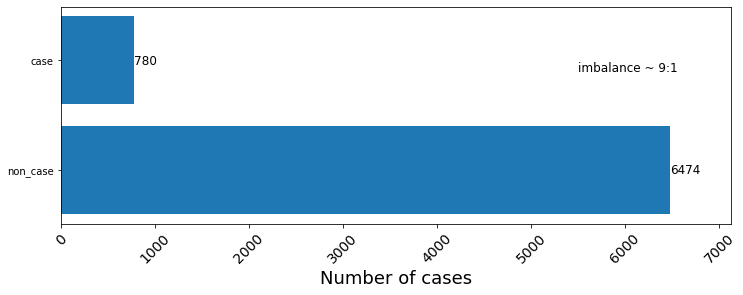

In [20]:
plot_imbalance(dataset)

In [21]:
path3 = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-June-1st.csv'
data_test = read_data(path3, exclude_years = years_to_remove)
data_test.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2023-06-01,κεντρικης μακεδονιας,αλεξανδρειας,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,478.8,38293.0,86.8,46.44911,0.235770,-0.062049,-0.236839,0.062049,0.214766,-0.074184,-0.225127,0.074184,0.062025,0.049040,0.047994,0.049040,22.027500,30.425,13.630000,11.533780,1.843800,12.127693,0.466225,22.192221,5.309037,25.273970,7.897753,3.816662,5.451688,110.235503,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,1010,0,0
1,21.94079,40.97703,2023-06-01,κεντρικης μακεδονιας,αλμωπιας,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,985.8,24924.0,28.0,46.48134,0.525521,0.260687,-0.404507,-0.260687,0.555146,0.286285,-0.424965,-0.286285,0.086064,0.060136,0.060803,0.060136,15.701000,21.662,9.740000,8.005546,2.551910,7.831732,0.138556,13.334987,3.903208,14.773962,5.972576,3.718226,48.967830,257.681940,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,62,0,0
2,22.89198,40.65603,2023-06-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.630,NaN,12.381429,3.596667,11.870000,2.525385,18.760769,5.121429,23.898000,11.870000,54.540328,73.751313,251.891959,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,174,0,0
3,23.98253,40.91510,2023-06-01,κεντρικης μακεδονιας,αμφιπολης,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,411.8,7169.0,22.3,47.42581,0.505204,0.326837,-0.385542,-0.326837,0.485806,0.292957,-0.381219,-0.292957,0.053260,0.065181,0.034598,0.065181,17.390833,23.465,11.316667,10.229485,3.130833,8.615636,0.482557,15.199095,4.675023,19.470028,6.606750,1.954789,11.972853,106.121052,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,79,20,79.0,20,79,9,9,4,1,1,2,0,395,0,0
4,23.69108,40.49593,2023-06-01,κεντρικης μακεδονιας,αριστοτελη,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,747.0,16994.0,24.5,46.91682,0.669556,0.329771,-0.542445,-0.329771,0.658577,0.359345,-0.526910,-0.359345,0.058441,0.046232,0.051163,0.046232,16.614643,22.765,10.464286,10.678026,3.098890,9.360022,1.950259,15.351957,4.242043,17.012319,6.938982,0.498732,18.989207,243.895665,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,63,0,0


In [22]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [23]:
data_train = dataset
data_test = data_test
    
data_train.reset_index(inplace = True, drop = True)
data_test.reset_index(inplace = True, drop = True)
    
X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
y_train = data_train['case']
X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
y_test = data_test['case']
    
X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
w0,w1 = calculate_weights(y_train)

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
results_train = results_train.append(train, ignore_index = True)
results_test = results_test.append(test, ignore_index = True)
coefficients.append(coef)
    
print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2023 || w0:1, w1:4 || ##


In [24]:
results_test.drop(columns='case', inplace= True)

results_test['Class Number - (Relative Risk Level)'] = pd.cut(results_test['probability'], bins=10, labels=False)

#bins_fixed = [0, 0.01, 0.25, 0.5, 0.75, 1]
bins_fixed = [0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]

# labels = ['Risk Class 1', 'Risk Class 2', 'Risk Class 3', 'Risk Class 4', 'Risk Class 5',
#           'Risk Class 6', 'Risk Class 7', 'Risk Class 8', 'Risk Class 9', 'Risk Class 10']

results_test['Class Number - (Risk Level)'] = pd.cut(results_test['probability'], bins=bins_fixed, labels=False, include_lowest=True)

results_test.head(40)

,x,y,municipality,day,month,year,probability,Class Number - (Relative Risk Level),Class Number - (Risk Level)
0,23.23930,41.12421,ηρακλειας,1,6,2023,0.271715,9,2
1,22.41285,40.81412,πελλας,1,6,2023,0.247717,9,2
2,22.14670,40.82294,σκυδρας,1,6,2023,0.185233,6,1
3,22.33660,40.28529,κατερινης,1,6,2023,0.183443,6,1
4,23.07574,40.48968,θερμης,1,6,2023,0.170357,6,1
5,22.48398,40.64468,αλεξανδρειας,1,6,2023,0.163474,5,1
6,23.62585,41.20990,σερρων,1,6,2023,0.157397,5,1
7,22.90326,40.67609,κορδελιου ευοσμου,1,6,2023,0.150771,5,1
8,22.87323,40.46715,θερμαϊκου,1,6,2023,0.147529,5,1
9,22.85103,41.02728,κιλκις,1,6,2023,0.145559,5,1


In [25]:
results_test.to_csv(f"../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Results_2023-{MONTH}-{PERIOD}.csv", encoding = enc, index = False)

In [26]:
greece_gdf = gpd.read_file(f"{shapefiles_folder}/elladitsa.shp",  encoding=enc)

In [27]:
greece_gdf.rename(columns={"NAME": "municipality"}, inplace = True)
greece_gdf.drop(columns='KWD_YPES', inplace= True)
process_greek(greece_gdf, 'municipality')

In [28]:
names_from_shape = greece_gdf["municipality"].drop_duplicates().sort_values().tolist()
names_from_results = results_test["municipality"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_results:
    if element not in names_from_shape:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [29]:
shapefile = pd.merge(greece_gdf, results_test, how='inner', on=['municipality'])

In [30]:
shapefile.sort_values(by='probability', ascending=False, inplace = True, ignore_index = True)

In [31]:
shapefile.head()

,municipality,geometry,x,y,day,month,year,probability,Class Number - (Relative Risk Level),Class Number - (Risk Level)
0,ηρακλειας,"POLYGON ((23.32249 41.23659, 23.32285 41.23655...",23.23930,41.12421,1,6,2023,0.271715,9,2
1,πελλας,"POLYGON ((22.29208 40.96846, 22.29293 40.96834...",22.41285,40.81412,1,6,2023,0.247717,9,2
2,σκυδρας,"POLYGON ((22.14406 40.91638, 22.14431 40.91628...",22.14670,40.82294,1,6,2023,0.185233,6,1
3,κατερινης,"POLYGON ((22.49274 40.40338, 22.49304 40.40335...",22.33660,40.28529,1,6,2023,0.183443,6,1
4,θερμης,"POLYGON ((23.10946 40.57892, 23.11119 40.57816...",23.07574,40.48968,1,6,2023,0.170357,6,1


In [32]:
shapefile.to_file(f"../../data/{NUTS2}/shapefiles/{NUTS0}_{NUTS2}_Results_2023-{MONTH}-{PERIOD}.shp", encoding = enc)